## Objective
### Forecasting Google Trends Using VAR and SARIMA Models
- Introduction: 
This project analyzes the relationship between Bitcoin search interest and the term "Crypto Crash" using Google Trends data. 

- The goal is to understand whether changes in one search trend can help predict movements in the other, so this project applies time series forecasting techniques such as VAR and SARIMA models.

The Project includes: 
- collect and analyze Google Trends data using the pytrends library.
- checking stationarity and integration order of the time series.
- performing Granger causality tests.
- buiding VAR and SARIMA forecasting models.
- generating out-of-sample forecasts.
- comparing model performance using RMSE and MAE metrics.

- The results will help determine whether multivariate (VAR) or univariate (SARIMA) models better capture and predict Google search behavior in the cryptocurrency market.
 



### Import Libraries

In [14]:
!pip install pytrends

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pytrends.request import TrendReq
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error

Defaulting to user installation because normal site-packages is not writeable


## Data Loading

In [16]:
from pytrends.request import TrendReq

pytrends = TrendReq()

kw_list = ["Bitcoin", "Crypto crash"]

pytrends.build_payload(kw_list,
                       timeframe='2021-01-01 2026-01-01',
                       geo='')

data = pytrends.interest_over_time()
data = data.drop(columns=['isPartial'])

# Save CSV 
data.to_csv("bitcoin_crypto_trends.csv", index=True)

data.head()

,Bitcoin,Crypto crash
date,,
2020-12-27,52,0
2021-01-03,86,0
2021-01-10,83,0
2021-01-17,53,0
2021-01-24,50,0


### Data Interpretation
- The dataset was collected using the pytrends library, which provides Google Trends data representing relative search interest over time. The analysis includes two keywords: “Bitcoin” and “Crypto crash”, covering the period from 2021 to 2026 at a global level.
- The values range between 0 and 100, where 100 represents the peak popularity of a search term within the selected timeframe. From the preview of the dataset, it can be observed that the “Bitcoin” series shows relatively continuous variation over time, reflecting general interest in the cryptocurrency market.
- The “Crypto crash” series contains many zero values with occasional spikes, indicating that searches related to market crashes occur irregularly and are concentrated around specific events. This suggests that “Crypto crash” captures sudden panic or crisis-driven behavior rather than consistent search activity.
- Additionally, the dataset is indexed by time and appears to follow a weekly frequency, which is typical for Google Trends data over long time horizons.

In [17]:
print(data.index[:10])
print(data.index.to_series().diff().value_counts())

DatetimeIndex(['2020-12-27', '2021-01-03', '2021-01-10', '2021-01-17',
               '2021-01-24', '2021-01-31', '2021-02-07', '2021-02-14',
               '2021-02-21', '2021-02-28'],
              dtype='datetime64[s]', name='date', freq=None)
date
7 days    261
Name: count, dtype: int64


## Initial Inspection

In [19]:
data = pd.read_csv("bitcoin_crypto_trends.csv", index_col=0, parse_dates=True)
data.head()


,Bitcoin,Crypto crash
date,,
2020-12-27,52,0
2021-01-03,86,0
2021-01-10,83,0
2021-01-17,53,0
2021-01-24,50,0


### Data Loading and Initial Inspection
The dataset was successfully loaded from the saved CSV file. The preview confirms that both variables are present and correctly indexed by date. This ensures the data is ready for further analysis.

## Stationary Test (Augmented Dickey-Fuller Test)

In [20]:
from statsmodels.tsa.stattools import adfuller

for col in data.columns:
    result = adfuller(data[col])
    print(f"Results for {col}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("----------------------")

Results for Bitcoin
ADF Statistic: -3.3406774826131818
p-value: 0.01315525866691327
----------------------
Results for Crypto crash
ADF Statistic: -6.0025995800449214
p-value: 1.643783188431306e-07
----------------------


### Stationarity Test (Augmented Dickey-Fuller Test):

#### Hypothesis:
- null hypothesis (H₀): The time series is non-stationary (has a unit root).
- Alternative hypothesis (H₁): The time series is stationary.

#### Result and Interpretation:
- The Augmented Dickey-Fuller (ADF) test results indicate that both “Bitcoin” and “Crypto crash” series are stationary, as their p-values are below the 0.05 significance level.
- In particular, the p-value for “crypto crash” is extremely close to zero, which provides strong statistical evidence against the presence of a unit root. This confirms that the series is highly stationary.
- Therefore, the null hypothesis of non-stationarity is rejected for both variables, and the original series can be directly used for further analysis without applying differencing.

### Verification

In [21]:
print(data.columns)

Index(['Bitcoin', 'Crypto crash'], dtype='str')


In [22]:
print(data.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 262 entries, 2020-12-27 to 2025-12-28
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Bitcoin       262 non-null    int64
 1   Crypto crash  262 non-null    int64
dtypes: int64(2)
memory usage: 6.1 KB
None


### Data Structure Verification
- The structure of the dataset was verified using the info() function. The output confirms that the date variable is correctly set as a DateTime index, which ensures that it is treated as a time reference rather than a variable in the analysis.
- The dataset contains two numerical variables, “Bitcoin” and “Crypto crash”, both of which have complete observations with no missing values and that means The data types are appropriate for time series analysis.
- This confirms that the dataset is properly formatted and suitable for applying statistical tests such as the Augmented Dickey-Fuller (ADF) test and further modeling techniques.

## Granger Causality Test
### Hypotheses
**Test 1: Bitcoin → Crypto crash**
- H₀: The first variable does NOT Granger-cause the second variable.
- H₁: The first variable DOES Granger-cause the second variable.
**Test 2: Crypto crash → Bitcoin**
- H₀: “crypto crash” does not Granger-cause Bitcoin
- H₁: “crypto crash” Granger-causes Bitcoin


In [23]:
from statsmodels.tsa.stattools import grangercausalitytests

grangercausalitytests(data[['Bitcoin', 'Crypto crash']], maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.5809  , p=0.0189  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=5.6458  , p=0.0175  , df=1
likelihood ratio test: chi2=5.5856  , p=0.0181  , df=1
parameter F test:         F=5.5809  , p=0.0189  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.4890  , p=0.0320  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=7.1147  , p=0.0285  , df=2
likelihood ratio test: chi2=7.0191  , p=0.0299  , df=2
parameter F test:         F=3.4890  , p=0.0320  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3856  , p=0.2477  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=4.2721  , p=0.2335  , df=3
likelihood ratio test: chi2=4.2373  , p=0.2370  , df=3
parameter F test:         F=1.3856  , p=0.2477  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.9229  , p=0.0218  

{np.int64(1): ({'ssr_ftest': (np.float64(5.580911602862954),
    np.float64(0.01890009537385209),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(5.645805923826476),
    np.float64(0.017497172168369542),
    np.int64(1)),
   'lrtest': (np.float64(5.585609017026854),
    np.float64(0.018108635489356883),
    np.int64(1)),
   'params_ftest': (np.float64(5.580911602863031),
    np.float64(0.01890009537385126),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.4889624277784046),
    np.float64(0.03199808908714054),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(7.114746911548118),
    np.float64(0.028513618726922586),
    np.int64(2)),
   'lrtest': (np.float64(7.019141681866813),
    np.float64(0.029909747722383532),
    np.int64(2)),
   'params_ftest': (np.float64(3.488962427778436),
    np.float64(0.03199808908713956),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
 

### Interpretation of Granger Causality Test:
#### Test 1:
- The Granger Causality Test was conducted to determine whether Bitcoin can predict Crypto Crash events.
- The null hypothesis states that Bitcoin does not Granger-cause Crypto Crash. 
- The results indicate statistically significant causality at lag lengths 1, 2, 4, and 5, the p-values obtained from the SSR-based F-test, Chi-square test, Likelihood Ratio test, and Parameter F-test are all below the 5% significance level. Therefore, the null hypothesis is rejected for these lags. This indicates that past Bitcoin values contain statistically significant information that helps predict future Crypto Crash movements.
- However, for lag 3, the p-values exceed 0.05, so the null hypothesis cannot be rejected at that lag. Overall, the evidence suggests the existence of Granger causality from Bitcoin to Crypto Crash, particularly at lag lengths 1, 2, 4, and 5.

## Reverse Causality 

In [24]:
grangercausalitytests(data[['Crypto crash', 'Bitcoin']], maxlag=5)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0749  , p=0.7846  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=0.0757  , p=0.7832  , df=1
likelihood ratio test: chi2=0.0757  , p=0.7832  , df=1
parameter F test:         F=0.0749  , p=0.7846  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0336  , p=0.9670  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=0.0685  , p=0.9663  , df=2
likelihood ratio test: chi2=0.0685  , p=0.9663  , df=2
parameter F test:         F=0.0336  , p=0.9670  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0788  , p=0.9714  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=0.2430  , p=0.9704  , df=3
likelihood ratio test: chi2=0.2429  , p=0.9704  , df=3
parameter F test:         F=0.0788  , p=0.9714  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.8001  , p=0.5261  

{np.int64(1): ({'ssr_ftest': (np.float64(0.07486886496648108),
    np.float64(0.7845942334129135),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.07573943316376575),
    np.float64(0.783156455187072),
    np.int64(1)),
   'lrtest': (np.float64(0.07572844589913075),
    np.float64(0.783171791076221),
    np.int64(1)),
   'params_ftest': (np.float64(0.07486886496646197),
    np.float64(0.7845942334129404),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.033591633718451745),
    np.float64(0.9669705786244722),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.06850058640625455),
    np.float64(0.9663296086332851),
    np.int64(2)),
   'lrtest': (np.float64(0.06849156427892922),
    np.float64(0.966333967817501),
    np.int64(2)),
   'params_ftest': (np.float64(0.03359163371846096),
    np.float64(0.9669705786244633),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],


### Interpretation of Reverse Causality Test
- A reverse Granger Causality Test was conducted to examine whether Crypto Crash events can predict Bitcoin movements.
-  The null hypothesis states that Crypto Crash does not Granger-cause Bitcoin. The results show that the p-values for all lag lengths (1–5) are greater than the 5% significance level.
- Therefore, the null hypothesis cannot be rejected. This indicates that past Crypto Crash values do not provide statistically significant information for predicting future Bitcoin movements.
- There is no evidence of Granger causality running from Crypto Crash to Bitcoin.

## VAR Model Specification and Lag Selection

In [25]:
from statsmodels.tsa.api import VAR

model = VAR(data)

lag_order_results = model.select_order(maxlags=10)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.8902      0.9183       2.436      0.9015
1      -0.2037    -0.1196*      0.8157    -0.1698*
2      -0.1853    -0.04521      0.8309     -0.1289
3      -0.1645     0.03158      0.8483    -0.08561
4      -0.1791     0.07297      0.8360    -0.07769
5     -0.2342*     0.07393     0.7913*     -0.1102
6      -0.2209      0.1432      0.8019    -0.07441
7      -0.2261      0.1941      0.7979    -0.05703
8      -0.1974      0.2788      0.8212   -0.005744
9      -0.1701      0.3621      0.8440     0.04400
10     -0.1563      0.4319      0.8559     0.08036
--------------------------------------------------


C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### Interpretation of VAR and Lag Selection
- To determine the optimal number of lags for the VAR model, several information criteria were used, including the Akaike Information Criterion (AIC), Bayesian Information Criterion (BIC), Final Prediction Error (FPE), and Hannan-Quinn Information Criterion (HQIC).
- The results indicate that AIC and FPE suggest using 5 lags, while BIC and HQIC point to a shorter lag length of 1. Since AIC is generally preferred in time series analysis for its ability to capture more detailed dynamic relationships, the model with 5 lags was chosen for further analysis.
- Moreover, selecting 5 lags is consistent with earlier Granger causality results, where stronger and more significant relationships were observed at higher lag values.

## VAR Model Estimation

In [26]:
var_model = model.fit(5)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 04, Jun, 2026
Time:                     21:19:33
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   0.168700
Nobs:                     257.000    HQIC:                -0.0129334
Log likelihood:          -689.973    FPE:                   0.873710
AIC:                    -0.135112    Det(Omega_mle):        0.803459
--------------------------------------------------------------------
Results for equation Bitcoin
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   3.920600         1.340642            2.924           0.003
L1.Bitcoin              0.730872         0.071185           10.267           0.000
L1.Crypto crash        -6.048903         4.038316 

### Interpretation of VAR Model Estimation
- The VAR model with 5 lags was used to study the relationship between Bitcoin and “crypto crash” searches.
- The results show that Bitcoin is mainly influenced by its own past values, indicating a strong persistence over time. In addition, “crypto crash” has a noticeable impact on Bitcoin, but only at certain lags, suggesting that this effect appears with some delay.
- Overall, Bitcoin behavior is mostly driven by its own trend, with some delayed influence from panic-related searches.

### Importance of Stationarity in VAR Modeling
- Stationarity is important when applying VAR models because it ensures that the statistical properties of the series, such as mean and variance, remain constant over time. This allows for reliable estimation and valid inference.
- Since both series were found to be stationary, the VAR model can be applied directly without transformation.

### Importance of Granger Causality Test in VAR Modeling
- Granger causality is important in VAR models because it helps identify whether one variable contains useful information for predicting another.
- In this analysis, Bitcoin was found to Granger-cause “crypto crash”, meaning that past Bitcoin search activity helps explain future changes in panic-related searches.
- This confirms that there is a meaningful dynamic relationship between the two variables, which justifies the use of a VAR model to capture their interaction.

### Fitted vs Actual Values
- The fitted values follow the actual data reasonably well, indicating that the VAR model is able to capture the main patterns in both series. Some differences remain, especially during sudden spikes, which is expected in volatile search data.

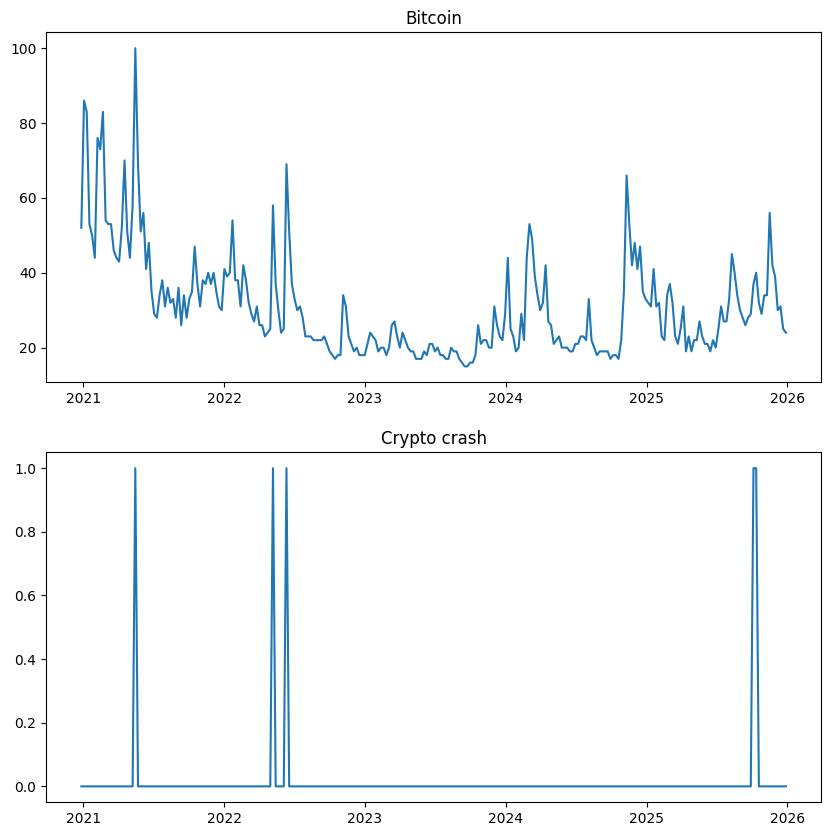

In [29]:
import matplotlib.pyplot as plt

var_model.plot()
plt.show()

### Interpretation: Bitcoin Plot
- This plot shows significant Volatility over the observed period from 2021 to 2026. In early yeras the series exhibits large fluctuations with values reaching peaks close to 100, that means periods of high market uncertainty and rapid price changes.
- From 2022 to 2023, the series enters a relatively stable phase, with values declining and fluctuating within a lower range (around 15–30). This suggests a period of reduced volatility and possibly market correction.
- From 2024 onwards, the Bitcoin series shows renewed fluctuations, with several sharp increases and decreases, though not as extreme as in earlier periods. This indicates that while volatility persists, the magnitude of fluctuations becomes more moderate over time.

### Interpretation: Crypto Crash Plot
- The crypto crash plot represents a binary variable indicating periods of significant market downturns (value = 1) and normal market conditions (value = 0).
- The graph shows that crash events are relatively rare and occur at specific points in time. Notable spikes are observed around 2021, 2022, and near 2026, suggesting that extreme negative movements in the cryptocurrency market are intermittent rather than continuous.
- These isolated spikes indicate that market crashes are sudden and short-lived events rather than prolonged periods of decline. This behavior is typical of financial markets, where extreme shocks occur infrequently but have significant impact.

## Residual Plots

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

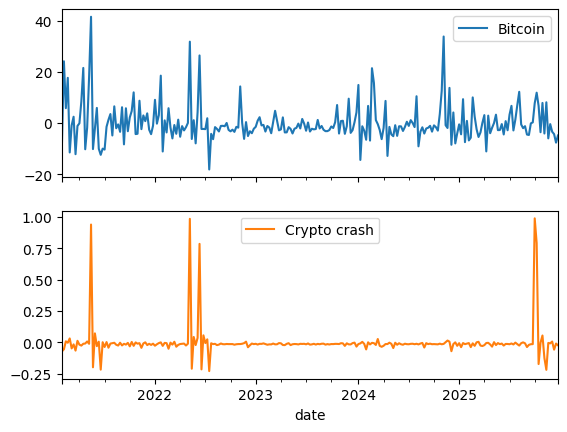

In [30]:
residuals = var_model.resid
residuals.plot(subplots=True)

### Residual Analysis
- The residual plots for both Bitcoin and “crypto crash” fluctuate around zero without showing any clear pattern or trend. This indicates that the model has successfully captured the underlying structure of the data.
- Although some spikes are present, especially in the “crypto crash” series, they are isolated and do not form any systematic pattern. This is expected given the nature of sudden panic-related searches.
- Overall, the residuals appear to behave like white noise, suggesting that the VAR model is well specified and provides a good fit to the data.

## ACF and PACF of Residuals

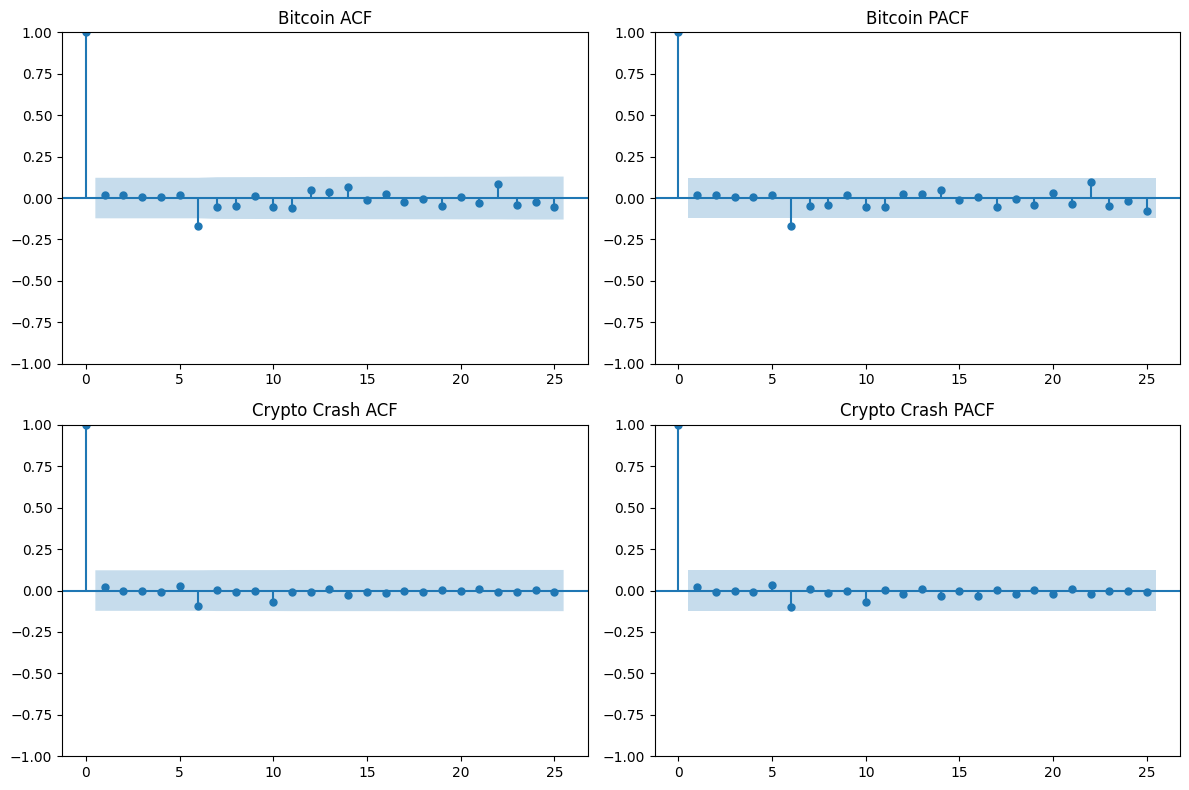

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(residuals['Bitcoin'], ax=ax[0,0])
ax[0,0].set_title('Bitcoin ACF')

plot_pacf(residuals['Bitcoin'], ax=ax[0,1])
ax[0,1].set_title('Bitcoin PACF')

plot_acf(residuals['Crypto crash'], ax=ax[1,0])
ax[1,0].set_title('Crypto Crash ACF')

plot_pacf(residuals['Crypto crash'], ax=ax[1,1])
ax[1,1].set_title('Crypto Crash PACF')

plt.tight_layout()
plt.show()

### Interpretation of ACF and PACF of Residuals
- The ACF and PACF plots for both Bitcoin and “crypto crash” residuals show that most autocorrelation values lie within the confidence bounds. This indicates that there is no significant autocorrelation remaining in the residuals.
- In simple terms, the residuals behave like white noise, meaning that the model has successfully captured the underlying patterns in the data.
-This confirms that the VAR model is well specified and provides a reliable representation of the relationship between the variables.

## Residual Autocorrelation Test
- To check whether the residuals are free from autocorrelation, the Ljung-Box test was applied. The results indicate that there is no significant autocorrelation in the residuals.
- This suggests that the VAR model adequately captures the dynamic relationships between the variables and is correctly specified.

In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Bitcoin residuals
acorr_ljungbox(residuals['Bitcoin'], lags=[10], return_df=True)

# Crypto crash residuals
acorr_ljungbox(residuals['Crypto crash'], lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,4.133561,0.941121


### Interpretation of Residual Autocorrelation Test
- The Ljung-Box test was applied to examine whether the residuals exhibit autocorrelation. The results show a high p-value (0.94), which is well above the 5% significance level. 
- This indicates that there is no significant autocorrelation in the residuals, meaning that the errors behave like white noise. Therefore, the VAR model is well specified and effectively captures the dynamics between Bitcoin and “crypto crash”.

### Alternative VAR Specification
- Before finalizing the VAR model, it is important to test alternative model specifications with different lag lengths and we can observe that the selected model is not only statistically optimal but also robust.
- Different lag structures may capture the dynamics between variables more effectively, so comparing multiple VAR models allows us to identify the best-performing specification.
- The final choice is made based on information criteria such as AIC, which balances model fit and complexity.
- so, several VAR models with different lag lengths were estimated and compared in order to confirm that the selected VAR(5) model is appropriate.

In [41]:
from statsmodels.tsa.api import VAR

model = VAR(data)

# Fit models with different lags
var_1 = model.fit(1)
var_2 = model.fit(2)
var_3 = model.fit(3)
var_4 = model.fit(4)
var_5 = model.fit(5)

# Compare using AIC
print("Lag 1 AIC:", var_1.aic)
print("Lag 2 AIC:", var_2.aic)
print("Lag 3 AIC:", var_3.aic)
print("Lag 4 AIC:", var_4.aic)
print("Lag 5 AIC:", var_5.aic)


Lag 1 AIC: 0.04199099645573817
Lag 2 AIC: -0.03934377506603387
Lag 3 AIC: -0.01673857510981569
Lag 4 AIC: -0.09663966634913493
Lag 5 AIC: -0.13511152205920612


C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### Interpretation of Alternative VAR Models Result:
- Different VAR models with lag lengths ranging from 1 to 5 were estimated and compared using the Akaike Information Criterion (AIC).
- The results show that the VAR model with 5 lags has the lowest AIC value (-0.1351), indicating the best balance between model fit and complexity.
- Therefore, the VAR(5) model is confirmed as the most appropriate specification for further analysis.

## Impulse Response Function:
- The impulse response function is used to analyze how a shock (or sudden change) in one variable affects another variable over time within the VAR model.
- In this context, IRF helps us understand how shocks to Bitcoin influence “crypto crash” searches, and vice versa. It allows us to observe both the direction and duration of these effects.
- By examining the response over several periods, we can identify whether the impact is temporary or persistent, and whether it reinforces or dampens the relationship between the variables.

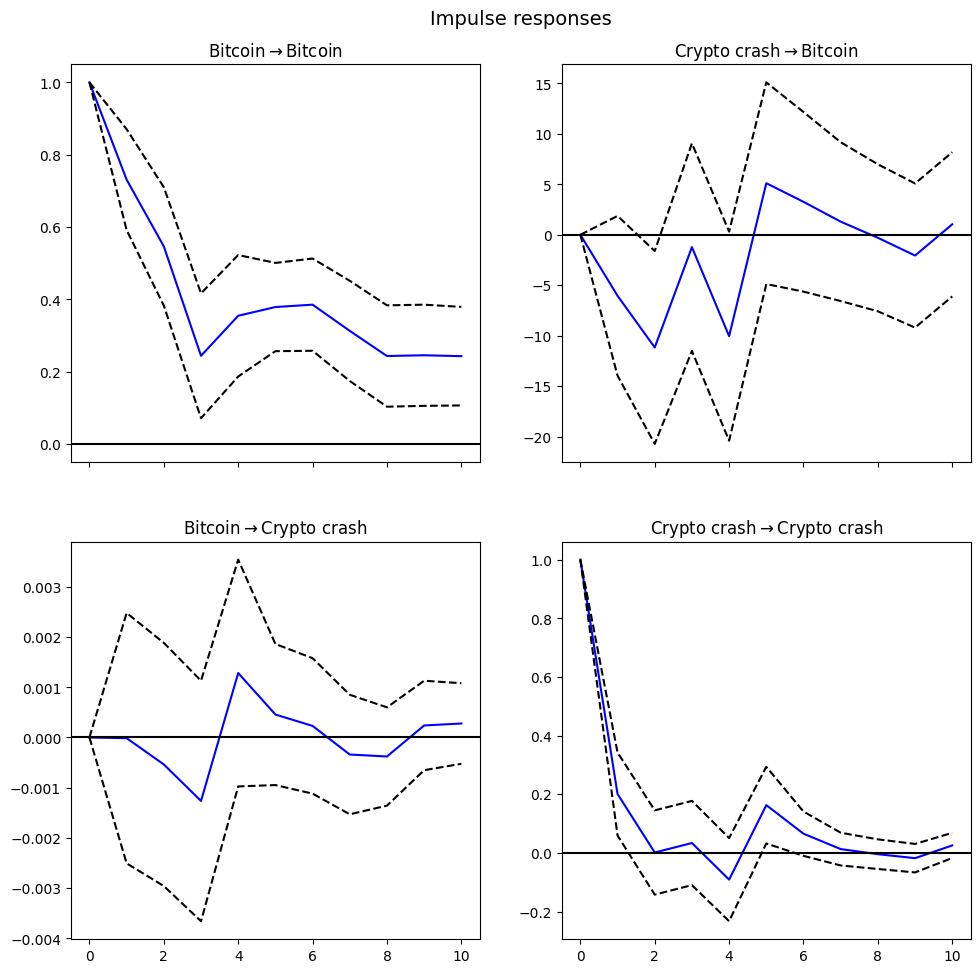

In [42]:
import matplotlib.pyplot as plt

irf = var_model.irf(10)
irf.plot()
plt.show()

### Interpretation of IRF
- As we can see that Bitcoin exhibits strong persistence, as shocks to Bitcoin have a large and gradually declining effect on itself. This means that Bitcoin dynamics are largely driven by its own past behavior.
- A Shock to Bitcoin also has noticeable positive effect on "Crypto Crash" searches in subsequent periods. This suggests that changes in Bitcoin activity can trigger increase in panic-related searches, although the impact is relatively weak and short-lived.
- In contrast, shocks to “crypto crash” have a limited and unstable effect on Bitcoin. The response fluctuates across periods and quickly fades, indicating that panic-related searches do not have strong predictive power for Bitcoin.
- Shocks to “crypto crash” itself show a sharp but short-lived response, reflecting the temporary nature of panic-driven search behavior.
- Overall, the results confirm that Bitcoin is the dominant variable in the system, driving the dynamics, while “crypto crash” plays a more reactive and short-term role. These findings are consistent with the earlier Granger causality results.

## Forecast Error Variance Decomposition:
Forecast Error Variance Decomposition (FEVD) is used to understand how much of the variation in each variable is explained by its own shocks and by shocks to other variables in the system.

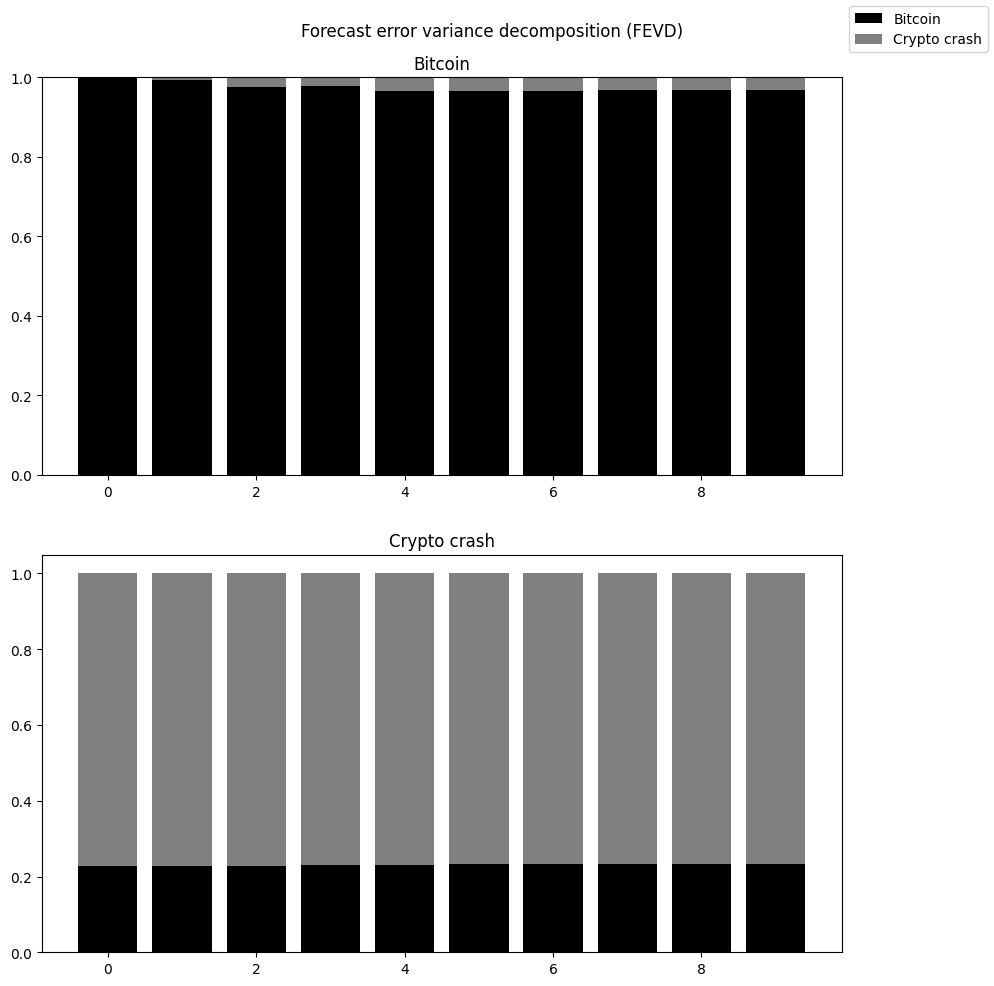

FEVD for Bitcoin
      Bitcoin  Crypto crash
0    1.000000      0.000000
1    0.993858      0.006142
2    0.976627      0.023373
3    0.977143      0.022857
4    0.964907      0.035093
5    0.964923      0.035077
6    0.966479      0.033521
7    0.967819      0.032181
8    0.968593      0.031407
9    0.968845      0.031155

FEVD for Crypto crash
      Bitcoin  Crypto crash
0    0.227436      0.772564
1    0.227331      0.772669
2    0.227970      0.772030
3    0.229977      0.770023
4    0.229168      0.770832
5    0.232420      0.767580
6    0.233087      0.766913
7    0.233173      0.766827
8    0.233548      0.766452
9    0.233512      0.766488


None


In [43]:
import matplotlib.pyplot as plt

fevd = var_model.fevd(10)
fevd.plot()
plt.show()
print(fevd.summary())

### Interpretation of Forecast Error Variance Decomposition Result:
- For Bitcoin, the results show that almost all of its variation (approximately 96%–100%) is explained by its own shocks across all periods. The contribution of “crypto crash” remains very small (around 3%–4%), indicating that Bitcoin is largely driven by its own dynamics.
- The variation in “crypto crash” is mainly explained by its own shocks (around 77%), but a notable portion (approximately 22%–23%) is explained by shocks to Bitcoin. This suggests that Bitcoin plays a significant role in influencing panic-related search behavior.
- Overall, these results indicate an asymmetric relationship, where Bitcoin acts as the dominant variable, while “crypto crash” is partially influenced by Bitcoin. This finding is consistent with the results obtained from the Granger causality test and impulse response analysis.

## VAR Forecasting
- After estimating and validating the VAR model, forecasting is performed to predict future values of both Bitcoin and “crypto crash” based on historical data.
- The VAR model uses the relationships between the variables to generate forecasts over a specified horizon. This allows us to evaluate how well the model captures the dynamics of the system and to analyze future trends.
- These forecasts will later be compared with actual values in the out-of-sample period to assess the accuracy of the model.

### Split Data (Train/Test)

In [44]:
# Split data
train = data[:-20]
test = data[-20:]

### Fit Model again (on TRAIN data)

In [45]:
from statsmodels.tsa.api import VAR

model = VAR(train)
var_model = model.fit(5)  # using chosen lag

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### Forecast

In [46]:
forecast_input = train.values[-var_model.k_ar:]

forecast = var_model.forecast(forecast_input, steps=20)

# Convert to DataFrame
import pandas as pd

forecast_df = pd.DataFrame(forecast, index=test.index, columns=data.columns)

### Plot Forecast vs Actual

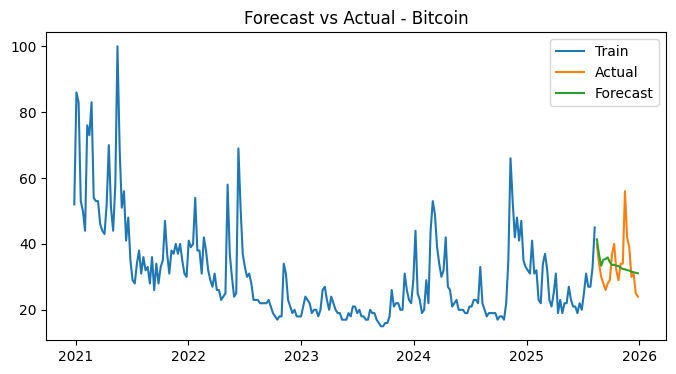

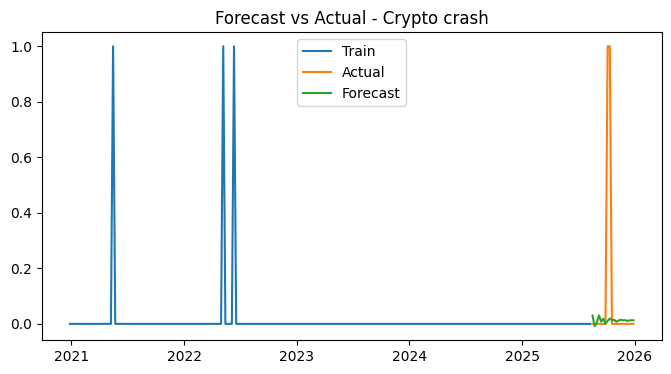

In [47]:
import matplotlib.pyplot as plt

for col in data.columns:
    plt.figure(figsize=(8,4))
    plt.plot(train[col], label='Train')
    plt.plot(test[col], label='Actual')
    plt.plot(forecast_df[col], label='Forecast')
    plt.title(f'Forecast vs Actual - {col}')
    plt.legend()
    plt.show()

### VAR Forecast Result 
- The VAR model was used to generate forecasts for both Bitcoin and “crypto crash” over the out-of-sample period.
- As we can see that for Bitcoin, forecasted values follow the general level and direction of the actual data, indicating that the model is able to capture the overall trend reasonably well but the model does not fully reflect sudden spikes, suggesting that it smooths out short-term volatility.
- The forecasts for “crypto crash” remain close to zero, reflecting the dominant pattern of the series, which consists mostly of low or zero values. While the model captures this baseline behavior effectively, it fails to predict sudden spikes observed in the actual data.
- Overall, the VAR model performs reasonably well for smoother time series like Bitcoin, but its performance is limited when dealing with highly irregular and event-driven data such as “crypto crash”.


### Forecast Accuracy Measure
RMSE is used to measure the accuracy of the VAR model forecasts. It calculates the average deviation between predicted and actual values, where a lower value indicates better performance.

In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Compute MSE first
mse_bitcoin = mean_squared_error(test['Bitcoin'], forecast_df['Bitcoin'])
mse_crash = mean_squared_error(test['Crypto crash'], forecast_df['Crypto crash'])

# Convert to RMSE
rmse_bitcoin = np.sqrt(mse_bitcoin)
rmse_crash = np.sqrt(mse_crash)

print("RMSE Bitcoin:", rmse_bitcoin)
print("RMSE Crypto crash:", rmse_crash)

RMSE Bitcoin: 7.531303524518902
RMSE Crypto crash: 0.3118429834251523


### Interpretation of Forecast Accuracy
- The forecasting performance of the VAR model was evaluated using the Root Mean Squared Error (RMSE).
- For Bitcoin, the RMSE value is approximately 7.53, indicating a moderate level of prediction error. This suggests that the model captures the overall trend reasonably well, although some deviations occur, particularly during periods of sudden fluctuations.
- For “crypto crash”, the RMSE value is relatively low (approximately 0.31). However, this low value reflects the fact that the series consists mostly of zero values, and the model predicts these baseline levels accurately. Despite this, the model fails to capture sudden spikes in the data.
- Overall, the VAR model provides reasonable accuracy for smoother series like Bitcoin but performs poorly in capturing rare and event-driven behavior such as “crypto crash” spikes.

## SARIMA Models 
- In addition to the VAR model, a univariate time series approach is applied using the Box-Jenkins methodology. The SARIMA model is used to analyze each time series individually without considering interactions between variables.
- SARIMA models are useful for capturing patterns such as autocorrelation, seasonality, and persistence within a single time series.

### Plot ACF & PACF 

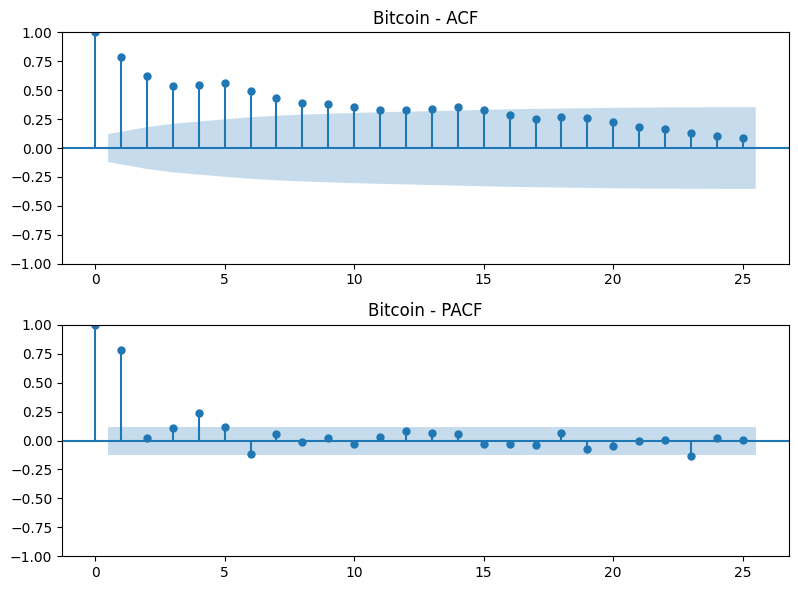

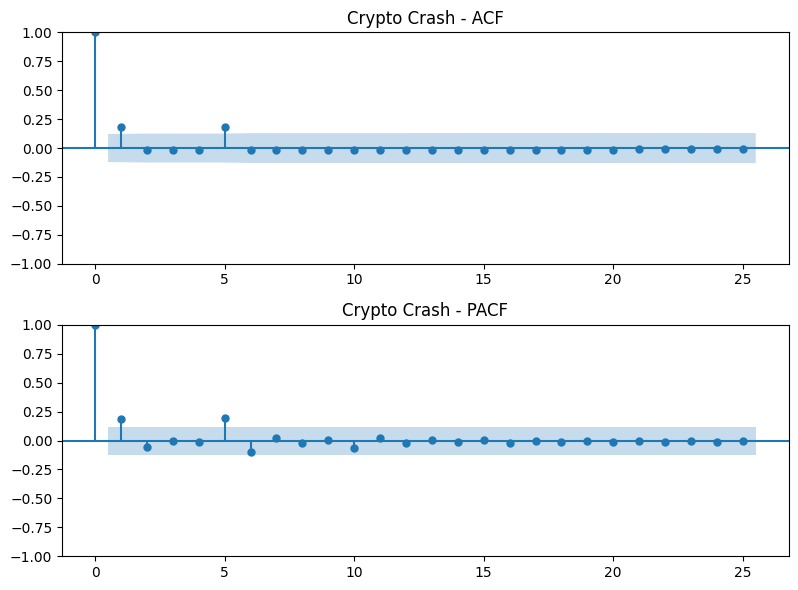

In [51]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -------- Bitcoin --------
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

plot_acf(data['Bitcoin'], ax=axes[0])
axes[0].set_title('Bitcoin - ACF')

plot_pacf(data['Bitcoin'], ax=axes[1])
axes[1].set_title('Bitcoin - PACF')

plt.tight_layout()
plt.show()


# -------- Crypto Crash --------
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

plot_acf(data['Crypto crash'], ax=axes[0])
axes[0].set_title('Crypto Crash - ACF')

plot_pacf(data['Crypto crash'], ax=axes[1])
axes[1].set_title('Crypto Crash - PACF')

plt.tight_layout()
plt.show()

### Identification using ACF and PACF
- The ACF and PACF plots were used to identify the model structure for both Bitcoin and “crypto crash”.
- For Bitcoin, the ACF declines gradually while the PACF shows a strong spike at lag 1. This suggests a simple AR(1) structure, and since the series is already stationary, no differencing is needed.
- In contrast, “crypto crash” shows very weak and irregular patterns, with most values close to zero. This indicates limited dependence on past values and reflects its spike-driven nature.
- Overall, an AR(1) structure is selected for both series, with seasonal components included only for Bitcoin due to its stronger persistence.

## Model Estimation
- Based on the identification step, SARIMA models are estimated for both Bitcoin and “crypto crash”. The selected models are fitted to the data in order to capture the underlying time series structure and obtain parameter estimates.

In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------- Bitcoin --------
model_btc = SARIMAX(
    data['Bitcoin'],
    order=(1,0,0),
    seasonal_order=(1,0,0,52)
)
result_btc = model_btc.fit()

# -------- Crypto crash --------
model_crash = SARIMAX(
    data['Crypto crash'],
    order=(1,0,0),
    seasonal_order=(0,0,0,52)
)
result_crash = model_crash.fit()

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra

In [55]:
result_btc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            Bitcoin   No. Observations:                  262
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 52)   Log Likelihood                -947.900
Date:                            Fri, 05 Jun 2026   AIC                           1901.799
Time:                                    17:05:12   BIC                           1912.504
Sample:                                12-27-2020   HQIC                          1906.102
                                     - 12-28-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9639      0.012     80.930      0.000       0.941       0.987
ar.S.L52       0.0369      0.059      0.628      0.530      -0.078       0.152
sigma2        80.4457      3.526     22.813      0.000      73.534      87.357
===================================================================================
Ljung-Box (L1) (Q):                   5.36   Jarque-Bera (JB):               542.44
Prob(Q):                              0.02   Prob(JB):                         0.00
Heteroskedasticity (H):               0.29   Skew:                             1.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [56]:
result_crash.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           Crypto crash   No. Observations:                  262
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 152.182
Date:                Fri, 05 Jun 2026   AIC                           -300.364
Time:                        17:05:33   BIC                           -293.228
Sample:                    12-27-2020   HQIC                          -297.496
                         - 12-28-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1992      0.021      9.396      0.000       0.158       0.241
sigma2         0.0183      0.000     54.855      0.000       0.018       0.019
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             24475.56
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.54   Skew:                             6.69
Prob(H) (two-sided):                  0.00   Kurtosis:                        48.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Interpretation of SARIMAX Result
- For Bitcoin, the model captures the strong persistence in the data, although some autocorrelation remains in the residuals, indicating that the model does not fully account for all underlying dynamics. 
- For “crypto crash”, the model performs better in terms of residual diagnostics, as it shows no significant autocorrelation. However, it fails to capture sudden spikes, reflecting the irregular and event-driven nature of the series.
- Overall, the results highlight that SARIMA models can effectively capture general patterns in the data, but may struggle with complex dynamics and rare extreme events.

### SARIMA Forecasting
The SARIMA models are used to generate forecasts for both Bitcoin and “crypto crash” over the out-of-sample period. These forecasts allow us to evaluate how well the models capture the individual behavior of each series.

In [57]:
btc_forecast = result_btc.forecast(steps=20)
crash_forecast = result_crash.forecast(steps=20)

### Plot Forecast vs Actual

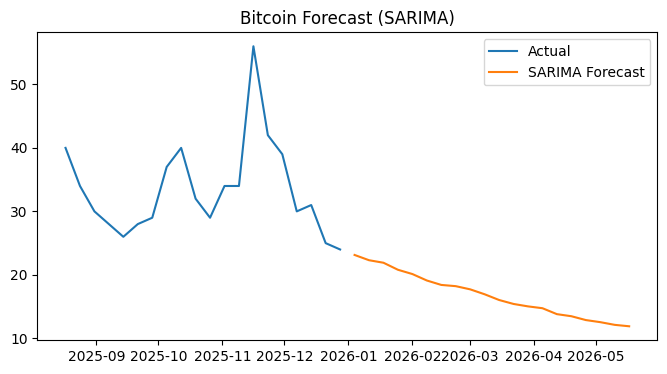

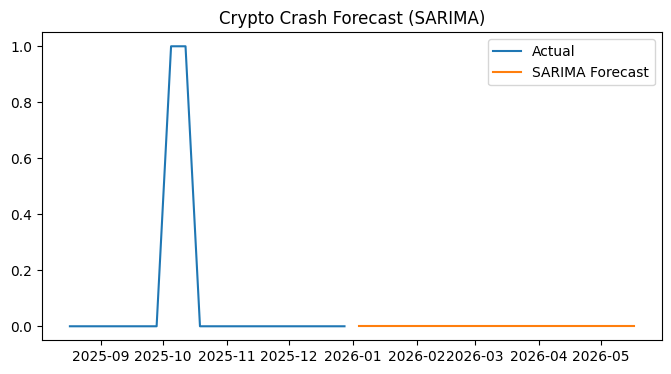

In [58]:
import matplotlib.pyplot as plt

# Bitcoin
plt.figure(figsize=(8,4))
plt.plot(test['Bitcoin'], label='Actual')
plt.plot(btc_forecast, label='SARIMA Forecast')
plt.title('Bitcoin Forecast (SARIMA)')
plt.legend()
plt.show()

# Crypto crash
plt.figure(figsize=(8,4))
plt.plot(test['Crypto crash'], label='Actual')
plt.plot(crash_forecast, label='SARIMA Forecast')
plt.title('Crypto Crash Forecast (SARIMA)')
plt.legend()
plt.show()

- The SARIMA models were used to forecast both Bitcoin and “crypto crash” over the test period.
- For Bitcoin, the model captures the general level of the series but misses sharp spikes and fluctuations. This shows that it follows the overall trend but struggles with short-term volatility.
- For “crypto crash”, the forecast stays close to zero, which reflects its usual pattern. However, the model fails to capture sudden spikes, as these rare events are difficult to predict.
- Overall, SARIMA models capture basic patterns well but have limitations in handling sudden and irregular movements.

### RMSE for SARIMA

In [59]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_btc_sarima = np.sqrt(mean_squared_error(test['Bitcoin'], btc_forecast))
rmse_crash_sarima = np.sqrt(mean_squared_error(test['Crypto crash'], crash_forecast))

print("SARIMA RMSE Bitcoin:", rmse_btc_sarima)
print("SARIMA RMSE Crypto crash:", rmse_crash_sarima)

SARIMA RMSE Bitcoin: 18.44193227550448
SARIMA RMSE Crypto crash: 0.31622776601683794


### Forecast Accuracy (SARIMA)
- The forecasting performance of the SARIMA model was evaluated using the Root Mean Squared Error (RMSE).
- For Bitcoin, the RMSE value is relatively high (18.44), indicating that the model has a larger prediction error. This suggests that SARIMA does not perform well for Bitcoin, as it struggles to capture its volatility and sudden fluctuations.
- For “crypto crash”, the RMSE value is low (approximately 0.32). However, this result is somewhat misleading because the series mostly contains zero values, and the model simply predicts this baseline pattern. Despite the low error, the model fails to capture sudden spikes.
- Overall, the SARIMA model performs poorly for Bitcoin and provides only a basic representation for “crypto crash”, highlighting its limitations in handling volatile and spike-driven data.


## Comparison of VAR and SARIMA Model
- The objective of this study was to determine which model, VAR or SARIMA, provides better forecasting performance for Bitcoin and Crypto Crash Google Trends data.
- The results indicate that the VAR model outperformed the SARIMA model in forecasting accuracy. For the Bitcoin series, the VAR model achieved a significantly lower RMSE value of 7.53 compared to 18.44 for SARIMA, indicating that VAR was able to produce forecasts that were much closer to the actual observations. For the Crypto Crash series, both models produced similar results, although VAR still showed a slight improvement.
- One possible reason for the superior performance of VAR is that it captures the relationship between multiple time series simultaneously. The Granger Causality analysis revealed that past Bitcoin search activity contains useful information for predicting Crypto Crash search activity.
- By incorporating this interaction, the VAR model was able to utilize additional information that SARIMA could not consider, since SARIMA models each variable independently.
- Furthermore, the residual diagnostic tests suggested that the VAR residuals behaved like white noise, meaning that most of the information present in the data had been successfully captured by the model. This indicates that the VAR model provides a better representation of the underlying dynamics of the series.
- Based on the forecasting accuracy, Granger causality results, and residual diagnostics, the VAR model is considered more suitable for forecasting Bitcoin and Crypto Crash search trends in this study. Therefore, VAR is selected as the preferred model for subsequent analysis and forecasting.

## Final Conclusion
- This study examined the relationship between Bitcoin and Crypto Crash Google Trends data using time series analysis techniques. 
- Before model development, stationarity tests confirmed that the transformed series were suitable for time series modelling. Granger Causality analysis revealed evidence that past Bitcoin search activity contains useful information for predicting Crypto Crash search activity, while the reverse relationship was not observed.
- To evaluate forecasting performance, both Vector Autoregression (VAR) and Seasonal ARIMA (SARIMA) models were developed and compared. 
- The results shows that the VAR model consistently outperformed the SARIMA model, particularly in forecasting Bitcoin search interest. The lower forecasting errors achieved by VAR indicate that incorporating interactions between multiple time series provides more accurate predictions than modelling each series independently.
- Residual diagnostic tests further confirmed that the VAR model adequately captured the underlying structure of the data, with residuals behaving close to white noise.
- Although both models faced difficulties in predicting rare and sudden crash events, VAR provided a more reliable representation of the dynamic relationship between the variables.
- Overall, the findings suggest that multivariate time series models are better suited for analysing interconnected financial and behavioural indicators such as Google search trends.
- The study highlights the importance of considering cross-variable relationships when forecasting cryptocurrency-related market sentiment. 
- Based on forecasting accuracy, statistical diagnostics, and causal analysis, the VAR model is recommended as the preferred approach for forecasting Bitcoin and Crypto Crash search behaviour.